# **6. Optimización**

In [ ]:
# --- Manejo y análisis de datos ---
import pandas as pd
import numpy as np
import math
from collections import Counter
import time
import joblib

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesamiento ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

# --- División y validación ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# --- Modelos supervisados ---
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# --- Manejo de desbalanceo ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Métricas de evaluación ---
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)

In [2]:
X_train = pd.read_csv('x_train_resampled.csv')
y_train = pd.read_csv('y_train_resampled.csv')["diabetes"]
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')["diabetes"]

In [3]:
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(include="object").columns

In [ ]:
# === Preprocesador ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="drop"
)

## **Modelo de `Regresión Logística L1 y L2`**

Aplicamos **Regresión Logística** porque es un modelo interpretable y adecuado para problemas 
de clasificación binaria. Además, permite obtener probabilidades asociadas a cada paciente, lo que es útil en contextos médicos.  

Para manejar el desbalance de clases (muchos más pacientes sin diabetes que con diabetes), 
usamos el parámetro `class_weight='balanced'`.


In [ ]:

pipe_reglog= Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("modelo",LogisticRegression(max_iter=5000, solver='saga',class_weight='balanced'))
])


# --- Búsqueda manual de mejores hiperparámetros ---
param_grid = [
    {'penalty': 'l1', 'C': 0.01},
    {'penalty': 'l1', 'C': 0.1},
    {'penalty': 'l1', 'C': 1},
    {'penalty': 'l2', 'C': 0.01},
    {'penalty': 'l2', 'C': 0.1},
    {'penalty': 'l2', 'C': 1},
]

resultados = []

for params in param_grid:
    start = time.time()
    modelo = LogisticRegression(
        penalty=params['penalty'],
        C=params['C'],
        solver='saga',
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    )
    pipe_reglog.set_params(modelo=modelo)
    pipe_reglog.fit(X_train, y_train)
    end = time.time()
    
    # Predicciones sobre el conjunto de prueba
    y_pred = pipe_reglog.predict(X_test)
    y_proba = pipe_reglog.predict_proba(X_test)[:, 1]
    
    resultados.append({
        'Penalty': params['penalty'],
        'C': params['C'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

# --- Convertir resultados en DataFrame ---
df_resultados = pd.DataFrame(resultados).sort_values(by='AUC', ascending=False)
display(df_resultados)

# --- Guardar el mejor modelo ---
best_params = df_resultados.iloc[0]
print("Mejor combinación:", best_params.to_dict())

best_model = LogisticRegression(
    penalty=best_params['Penalty'],
    C=best_params['C'],
    solver='saga',
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

final_pipe_reglog = Pipeline([
    ("preprocesamiento", preprocessor),
    ("modelo", best_model)
])

final_pipe_reglog.fit(X_train, y_train)


Probando: {'penalty': 'l1', 'C': 0.01}
Probando: {'penalty': 'l1', 'C': 0.1}
Probando: {'penalty': 'l1', 'C': 1}
Probando: {'penalty': 'l2', 'C': 0.01}
Probando: {'penalty': 'l2', 'C': 0.1}
Probando: {'penalty': 'l2', 'C': 1}


,Penalty,C,AUC,F1,Recall,Accuracy,Tiempo (s)
0,l1,0.01,0.788835,0.409985,0.707582,0.720110,14.89
1,l1,0.10,0.788207,0.409192,0.708370,0.718877,12.90
2,l1,1.00,0.788134,0.408912,0.708370,0.718552,12.99
5,l2,1.00,0.788111,0.409040,0.708370,0.718701,11.51
4,l2,0.10,0.788015,0.409157,0.707483,0.719189,11.39
3,l2,0.01,0.788014,0.409518,0.703342,0.721248,11.31



🏆 Mejor combinación: {'Penalty': 'l1', 'C': 0.01, 'AUC': 0.7888349993562084, 'F1': 0.4099854331495816, 'Recall': 0.7075815833579808, 'Accuracy': 0.7201100211370658, 'Tiempo (s)': 14.89}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.7201100211370658

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.72      0.82     63661
           1       0.29      0.71      0.41     10143

    accuracy                           0.72     73804
   macro avg       0.61      0.71      0.61     73804
weighted avg       0.85      0.72      0.76     73804



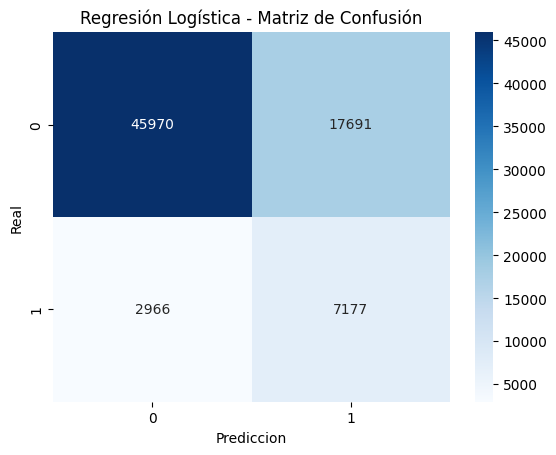

In [ ]:
# === Probabilidades y baseline ===
y_proba_lg = final_pipe_reglog.predict_proba(X_test)[:, 1]
y_pred_lg = final_pipe_reglog.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_lg == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_lg))

cm = confusion_matrix(y_test, y_pred_lg)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"Regresión Logística - Matriz de Confusión")
plt.show()



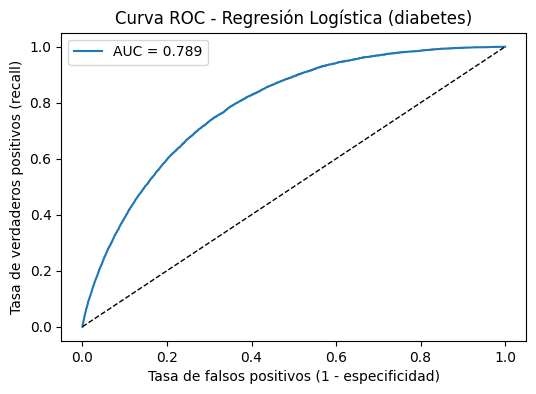

In [ ]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_lg)
roc_auc = roc_auc_score(y_test, y_proba_lg)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - Regresión Logística (diabetes)")
plt.legend()
plt.show()


## **Modelo de ``KNN_NeighborsClassifier``**

In [18]:
# --- Pipeline base ---
pipe_knn = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', KNeighborsClassifier())
])

# --- Grid manual de hiperparámetros ---
param_grid = [
    {'n_neighbors': 3,  'weights': 'uniform', 'metric': 'minkowski'},
    {'n_neighbors': 5,  'weights': 'uniform', 'metric': 'minkowski'},
    {'n_neighbors': 7,  'weights': 'distance', 'metric': 'minkowski'},
    {'n_neighbors': 9,  'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'}
]

# --- Entrenamiento y evaluación simple ---
resultados = []
for params in param_grid:
    print(f"Probando: {params}")
    start = time.time()
    
    modelo = KNeighborsClassifier(
        n_neighbors=params['n_neighbors'],
        weights=params['weights'],
        metric=params['metric']
    )
    pipe_knn.set_params(model=modelo)
    pipe_knn.fit(X_train, y_train)
    
    y_pred = pipe_knn.predict(X_test)
    y_proba = pipe_knn.predict_proba(X_test)[:, 1]
    
    end = time.time()
    resultados.append({
        'n_neighbors': params['n_neighbors'],
        'weights': params['weights'],
        'metric': params['metric'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

# --- Resultados ordenados ---
df_resultados_knn = pd.DataFrame(resultados).sort_values(by='AUC', ascending=False)
display(df_resultados_knn)

# --- Elegir mejor combinación ---
best = df_resultados_knn.iloc[0]
print(f"\n Mejor combinación: {best.to_dict()}")

# --- Entrenar modelo final con esos hiperparámetros ---
best_model = KNeighborsClassifier(
    n_neighbors=int(best['n_neighbors']),
    weights=best['weights'],
    metric=best['metric']
)

final_pipe_knn = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', best_model)
])

final_pipe_knn.fit(X_train, y_train)

Probando: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'minkowski'}
Probando: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'minkowski'}
Probando: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski'}
Probando: {'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean'}
Probando: {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'}


,n_neighbors,weights,metric,AUC,F1,Recall,Accuracy,Tiempo (s)
4,11,distance,manhattan,0.754779,0.380990,0.671399,0.700165,515.17
3,9,distance,euclidean,0.748408,0.374464,0.697131,0.679909,121.23
2,7,distance,minkowski,0.742319,0.372413,0.676920,0.686453,122.10
1,5,uniform,minkowski,0.730528,0.367637,0.655625,0.690030,121.72
0,3,uniform,minkowski,0.708978,0.357956,0.603175,0.702631,121.60



 Mejor combinación: {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan', 'AUC': 0.7547790485100311, 'F1': 0.380989678032952, 'Recall': 0.6713989943803609, 'Accuracy': 0.700165302693621, 'Tiempo (s)': 515.17}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.700165302693621

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80     63661
           1       0.27      0.67      0.38     10143

    accuracy                           0.70     73804
   macro avg       0.60      0.69      0.59     73804
weighted avg       0.84      0.70      0.74     73804



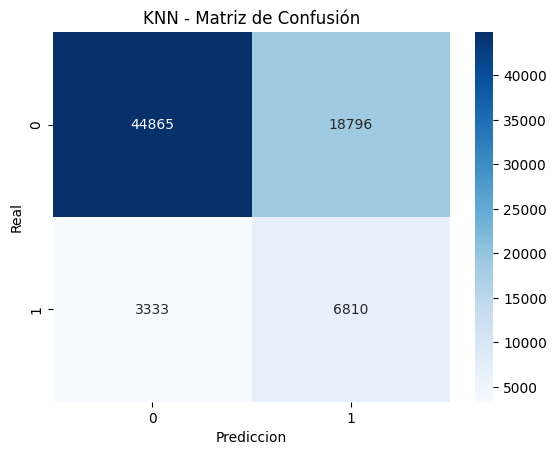

In [ ]:
y_proba_knn = final_pipe_knn.predict_proba(X_test)[:, 1]
y_pred_knn = final_pipe_knn.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_knn == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"KNN - Matriz de Confusión")
plt.show()


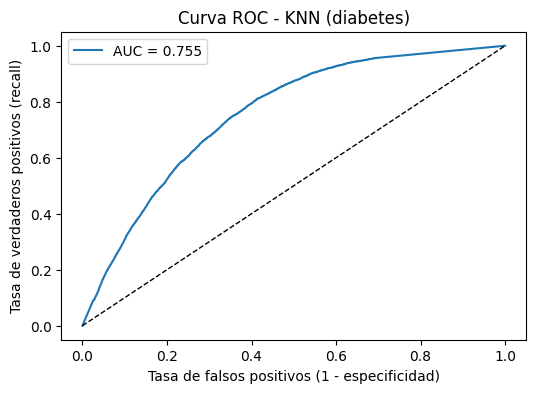

In [ ]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
roc_auc = roc_auc_score(y_test, y_proba_knn)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - KNN (diabetes)")
plt.legend()
plt.show()


## **Modelo de ``Naive Bayes``**

In [22]:
pipe_nb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', GaussianNB())
])

# No hay muchos hiperparámetros, pero puedes probar var_smoothing
param_grid_nb = [
    {'var_smoothing': 1e-9},
    {'var_smoothing': 1e-8},
    {'var_smoothing': 1e-7},
    {'var_smoothing': 1e-6}
]

resultados_nb = []
for params in param_grid_nb:
    print(f"Probando: {params}")
    start = time.time()

    modelo = GaussianNB(var_smoothing=params['var_smoothing'])
    pipe_nb.set_params(model=modelo)
    pipe_nb.fit(X_train, y_train)

    y_pred = pipe_nb.predict(X_test)
    y_proba = pipe_nb.predict_proba(X_test)[:, 1]

    end = time.time()
    resultados_nb.append({
        'var_smoothing': params['var_smoothing'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

df_resultados_nb = pd.DataFrame(resultados_nb).sort_values(by='AUC', ascending=False)
display(df_resultados_nb)

best_nb = df_resultados_nb.iloc[0]
print(f"Mejor combinación: {best_nb.to_dict()}")

final_pipe_nb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', GaussianNB(var_smoothing=best_nb['var_smoothing']))
])
final_pipe_nb.fit(X_train, y_train)


Probando: {'var_smoothing': 1e-09}
Probando: {'var_smoothing': 1e-08}
Probando: {'var_smoothing': 1e-07}
Probando: {'var_smoothing': 1e-06}


,var_smoothing,AUC,F1,Recall,Accuracy,Tiempo (s)
3,1.000000e-06,0.738945,0.315209,0.833876,0.50206,2.61
2,1.000000e-07,0.738943,0.315209,0.833876,0.50206,2.58
0,1.000000e-09,0.738943,0.315209,0.833876,0.50206,2.57
1,1.000000e-08,0.738943,0.315209,0.833876,0.50206,2.51


Mejor combinación: {'var_smoothing': 1e-06, 'AUC': 0.738944594629467, 'F1': 0.3152088845824172, 'Recall': 0.8338755792171941, 'Accuracy': 0.5020595089697035, 'Tiempo (s)': 2.61}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.5020595089697035

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.45      0.61     63661
           1       0.19      0.83      0.32     10143

    accuracy                           0.50     73804
   macro avg       0.57      0.64      0.46     73804
weighted avg       0.84      0.50      0.57     73804



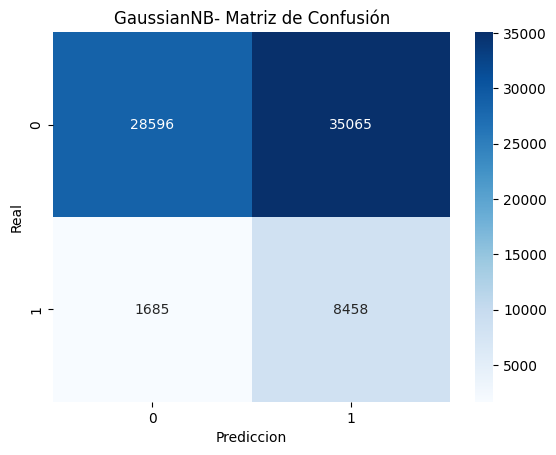

In [ ]:
y_proba_nb = final_pipe_nb.predict_proba(X_test)[:, 1]
y_pred_nb = final_pipe_nb.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_nb == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"GaussianNB- Matriz de Confusión")
plt.show()

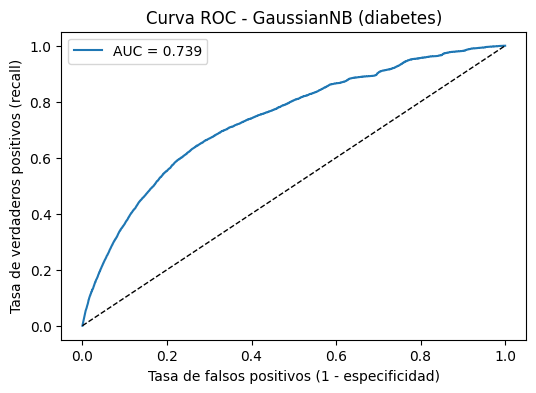

In [ ]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_nb)
roc_auc = roc_auc_score(y_test, y_proba_nb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - GaussianNB (diabetes)")
plt.legend()
plt.show()


## **Modelo de ``DecisionTreeClassifier``**

In [25]:
pipe_tree = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = [
    {'max_depth': 3, 'criterion': 'gini'},
    {'max_depth': 5, 'criterion': 'entropy'},
    {'max_depth': 7, 'criterion': 'gini'},
    {'max_depth': 10, 'criterion': 'entropy'}
]

resultados_tree = []
for params in param_grid_tree:
    print(f"Probando: {params}")
    start = time.time()

    modelo = DecisionTreeClassifier(
        max_depth=params['max_depth'],
        criterion=params['criterion'],
        random_state=42
    )
    pipe_tree.set_params(model=modelo)
    pipe_tree.fit(X_train, y_train)

    y_pred = pipe_tree.predict(X_test)
    y_proba = pipe_tree.predict_proba(X_test)[:, 1]

    end = time.time()
    resultados_tree.append({
        'max_depth': params['max_depth'],
        'criterion': params['criterion'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

df_resultados_tree = pd.DataFrame(resultados_tree).sort_values(by='AUC', ascending=False)
display(df_resultados_tree)

best_tree = df_resultados_tree.iloc[0]
print(f"Mejor combinación: {best_tree.to_dict()}")

final_pipe_tree = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=int(best_tree['max_depth']),
        criterion=best_tree['criterion'],
        random_state=42))
])
final_pipe_tree.fit(X_train, y_train)

Probando: {'max_depth': 3, 'criterion': 'gini'}
Probando: {'max_depth': 5, 'criterion': 'entropy'}
Probando: {'max_depth': 7, 'criterion': 'gini'}
Probando: {'max_depth': 10, 'criterion': 'entropy'}


,max_depth,criterion,AUC,F1,Recall,Accuracy,Tiempo (s)
3,10,entropy,0.748901,0.376821,0.611949,0.721831,5.68
2,7,gini,0.748507,0.374721,0.712018,0.673432,4.56
1,5,entropy,0.738293,0.362094,0.687864,0.666915,4.08
0,3,gini,0.712503,0.323408,0.848073,0.512330,3.27


Mejor combinación: {'max_depth': 10, 'criterion': 'entropy', 'AUC': 0.7489013065009016, 'F1': 0.37682127246236036, 'Recall': 0.6119491274770777, 'Accuracy': 0.7218307950788575, 'Tiempo (s)': 5.68}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.8004850685599697

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88     63661
           1       0.27      0.26      0.27     10143

    accuracy                           0.80     73804
   macro avg       0.58      0.57      0.58     73804
weighted avg       0.80      0.80      0.80     73804



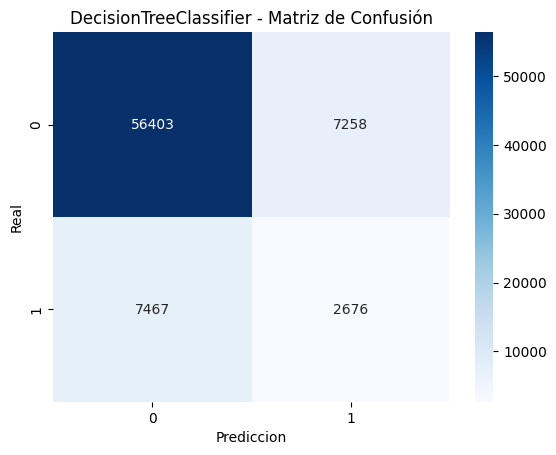

In [ ]:
y_proba_tree = final_pipe_tree.predict_proba(X_test)[:, 1]
y_pred_tree = final_pipe_tree.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_tree == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"DecisionTreeClassifier - Matriz de Confusión")
plt.show()

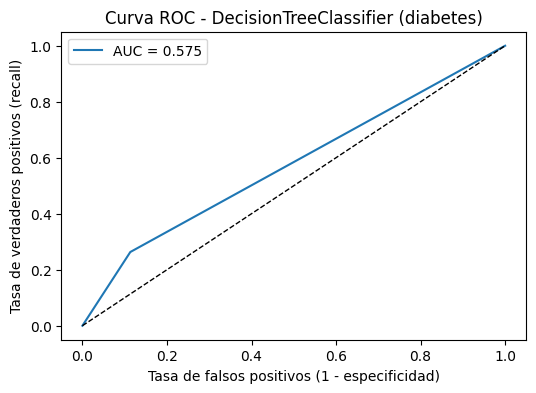

In [39]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_auc = roc_auc_score(y_test, y_proba_tree)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - DecisionTreeClassifier (diabetes)")
plt.legend()
plt.show()

## **Modelo de ``RandomForestClassifier``**

In [ ]:
pipe_rf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = [
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 200, 'max_depth': 7},
    {'n_estimators': 300, 'max_depth': 10},
    {'n_estimators': 500, 'max_depth': None}
]

resultados_rf = []
for params in param_grid_rf:
    print(f"Probando: {params}")
    start = time.time()

    modelo = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    pipe_rf.set_params(model=modelo)
    pipe_rf.fit(X_train, y_train)

    y_pred = pipe_rf.predict(X_test)
    y_proba = pipe_rf.predict_proba(X_test)[:, 1]

    end = time.time()
    resultados_rf.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

df_resultados_rf = pd.DataFrame(resultados_rf).sort_values(by='AUC', ascending=False)
display(df_resultados_rf)

best_rf = df_resultados_rf.iloc[0]
print(f"Mejor combinación: {best_rf.to_dict()}")

final_pipe_rf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=int(best_rf['n_estimators']),
        max_depth=None if pd.isna(best_rf['max_depth']) else int(best_rf['max_depth']),
        random_state=42,
        n_jobs=-1))
])
final_pipe_rf.fit(X_train, y_train)



Probando: {'n_estimators': 100, 'max_depth': 5}
Probando: {'n_estimators': 200, 'max_depth': 7}
Probando: {'n_estimators': 300, 'max_depth': 10}
Probando: {'n_estimators': 500, 'max_depth': None}


,n_estimators,max_depth,AUC,F1,Recall,Accuracy,Tiempo (s)
3,500,NaN,0.794985,0.381757,0.382924,0.829549,88.81
2,300,10.0,0.787559,0.413914,0.709159,0.723999,35.00
1,200,7.0,0.782295,0.405278,0.731243,0.705057,20.78
0,100,5.0,0.778820,0.398362,0.743271,0.691453,11.20


Mejor combinación: {'n_estimators': 500.0, 'max_depth': nan, 'AUC': 0.794985439696297, 'F1': 0.38175742087674464, 'Recall': 0.3829241841664202, 'Accuracy': 0.8295485339547992, 'Tiempo (s)': 88.81}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.8639504633895182

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93     63661
           1       0.53      0.08      0.14     10143

    accuracy                           0.86     73804
   macro avg       0.70      0.54      0.54     73804
weighted avg       0.82      0.86      0.82     73804



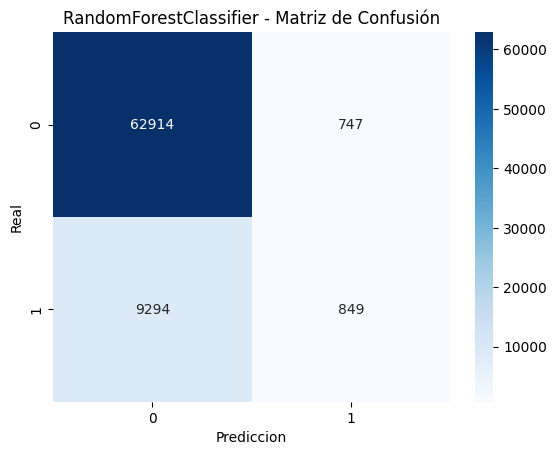

In [ ]:
y_proba_rf = final_pipe_rf.predict_proba(X_test)[:, 1]
y_pred_rf = final_pipe_rf.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_rf == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"RandomForestClassifier - Matriz de Confusión")
plt.show()

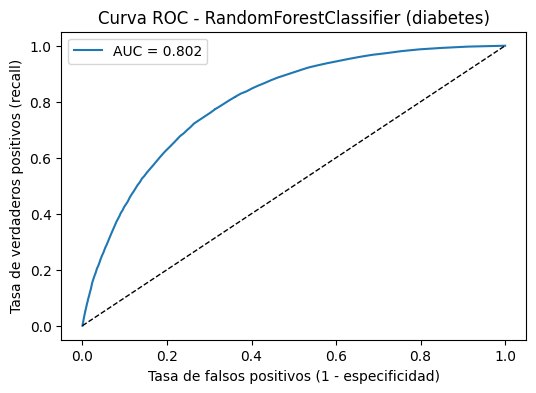

In [45]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - RandomForestClassifier (diabetes)")
plt.legend()
plt.show()

## **Modelo de ``XGBClassifier``**

In [ ]:
pipe_xgb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

param_grid_xgb = [
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.03}
]

resultados_xgb = []
for params in param_grid_xgb:
    print(f"Probando: {params}")
    start = time.time()

    modelo = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    pipe_xgb.set_params(model=modelo)
    pipe_xgb.fit(X_train, y_train)

    y_pred = pipe_xgb.predict(X_test)
    y_proba = pipe_xgb.predict_proba(X_test)[:, 1]

    end = time.time()
    resultados_xgb.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

df_resultados_xgb = pd.DataFrame(resultados_xgb).sort_values(by='AUC', ascending=False)
display(df_resultados_xgb)

best_xgb = df_resultados_xgb.iloc[0]
print(f"Mejor combinación: {best_xgb.to_dict()}")

final_pipe_xgb = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=int(best_xgb['n_estimators']),
        max_depth=int(best_xgb['max_depth']),
        learning_rate=float(best_xgb['learning_rate']),
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1))
])
final_pipe_xgb.fit(X_train, y_train)


Probando: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Probando: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}
Probando: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.03}


,n_estimators,max_depth,learning_rate,AUC,F1,Recall,Accuracy,Tiempo (s)
2,300,8,0.03,0.804975,0.353641,0.296165,0.851214,15.00
1,200,6,0.05,0.803542,0.373304,0.330869,0.847325,10.13
0,100,4,0.10,0.797888,0.402216,0.411614,0.831852,7.47


Mejor combinación: {'n_estimators': 300.0, 'max_depth': 8.0, 'learning_rate': 0.03, 'AUC': 0.8049746659866686, 'F1': 0.35364059097062805, 'Recall': 0.2961648427486937, 'Accuracy': 0.8512140263400357, 'Tiempo (s)': 15.0}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.8660370711614547

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     63661
           1       0.55      0.14      0.22     10143

    accuracy                           0.87     73804
   macro avg       0.71      0.56      0.57     73804
weighted avg       0.83      0.87      0.83     73804



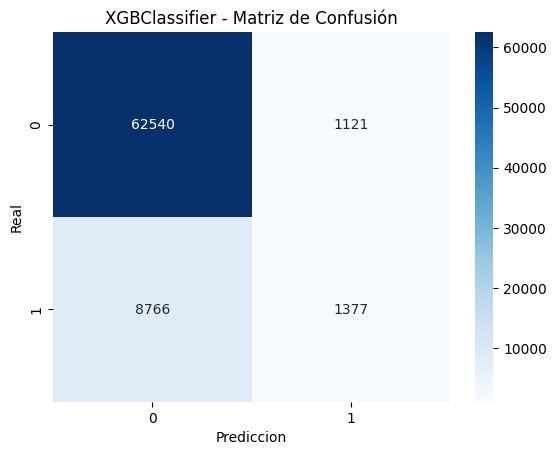

In [48]:
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb= pipe_xgb.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_xgb == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"XGBClassifier - Matriz de Confusión")
plt.show()

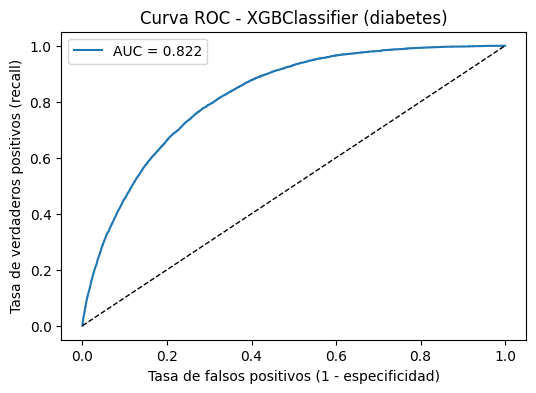

In [49]:
# === Curva ROC ===
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc = roc_auc_score(y_test, y_proba_xgb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC - XGBClassifier (diabetes)")
plt.legend()
plt.show()

## **Modelo de ``LinearSVC``**

In [ ]:
pipe_svm = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', CalibratedClassifierCV(LinearSVC(max_iter=5000, class_weight='balanced'), cv=3))
])

param_grid_svm = [
    {'model__base_estimator__C': 0.01},
    {'model__base_estimator__C': 0.1},
    {'model__base_estimator__C': 1},
    {'model__base_estimator__C': 10}
]

resultados_svm = []
for params in param_grid_svm:
    print(f"Probando: {params}")
    start = time.time()

    modelo = CalibratedClassifierCV(
        LinearSVC(C=params['model__base_estimator__C'], max_iter=5000, class_weight='balanced'),
        cv=3
    )
    pipe_svm.set_params(model=modelo)
    pipe_svm.fit(X_train, y_train)

    y_pred = pipe_svm.predict(X_test)
    y_proba = pipe_svm.predict_proba(X_test)[:, 1]

    end = time.time()
    resultados_svm.append({
        'C': params['model__base_estimator__C'],
        'AUC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Tiempo (s)': round(end - start, 2)
    })

df_resultados_svm = pd.DataFrame(resultados_svm).sort_values(by='AUC', ascending=False)
display(df_resultados_svm)

best_svm = df_resultados_svm.iloc[0]
print(f"Mejor combinación: {best_svm.to_dict()}")

final_pipe_svm = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', CalibratedClassifierCV(
        LinearSVC(C=best_svm['C'], max_iter=5000, class_weight='balanced'), cv=3))
])
final_pipe_svm.fit(X_train, y_train)



Probando: {'model__base_estimator__C': 0.01}
Probando: {'model__base_estimator__C': 0.1}
Probando: {'model__base_estimator__C': 1}
Probando: {'model__base_estimator__C': 10}


,C,AUC,F1,Recall,Accuracy,Tiempo (s)
0,0.01,0.789010,0.411831,0.706300,0.722739,13.95
1,0.10,0.788641,0.410942,0.707976,0.721058,14.93
2,1.00,0.788584,0.411057,0.708863,0.720842,17.95
3,10.00,0.788576,0.411067,0.708962,0.720815,18.01


Mejor combinación: {'C': 0.01, 'AUC': 0.78900985243885, 'F1': 0.41183064585668705, 'Recall': 0.7062999112688554, 'Accuracy': 0.722738604953661, 'Tiempo (s)': 13.95}


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


== Métricas con threshold ==
Accuracy: 0.8661996639748523

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93     63661
           1       0.55      0.15      0.23     10143

    accuracy                           0.87     73804
   macro avg       0.71      0.56      0.58     73804
weighted avg       0.83      0.87      0.83     73804



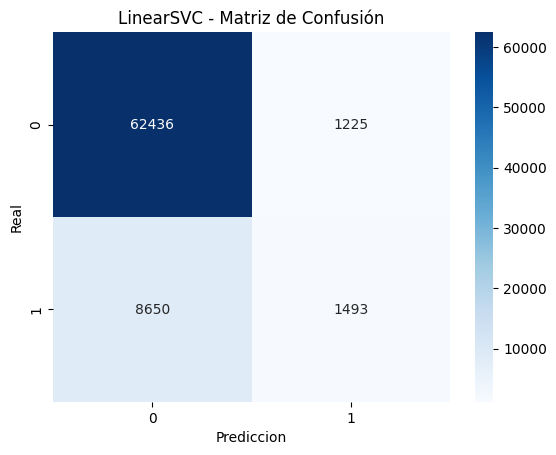

In [31]:
y_proba_svm = pipe_svm.predict_proba(X_test)[:, 1]
y_pred_svm= pipe_svm.predict(X_test)

print("== Métricas con threshold ==")
print("Accuracy:", (y_pred_svm == y_test).mean())
print("\nClassification report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title(f"LinearSVC - Matriz de Confusión")
plt.show()

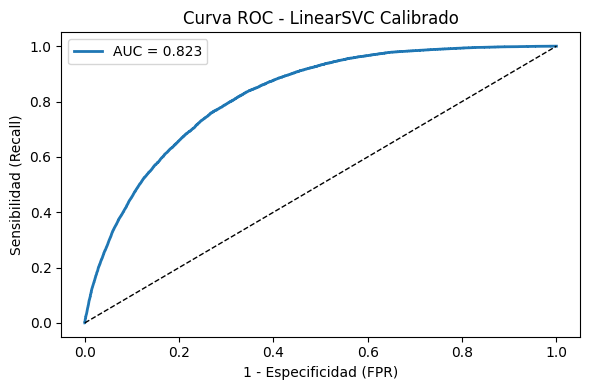

In [32]:

fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
roc_auc = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0,1], [0,1], "k--", linewidth=1)
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (Recall)")
plt.title("Curva ROC - LinearSVC Calibrado")
plt.legend()
plt.tight_layout()
plt.show()
